# Customer Personality Analysis Cleaning Notebook

**By: Izzatlhanim Mirzakhanova**

This notebook cleans the marketing campaign dataset and prepares the final cleaned CSV for clustering.

The main cleaning points are missing income values, weird marital status values, and the large income outlier.


## Setup

Importing the libraries used for data cleaning, tables, and graphs.


In [49]:
import ssl
from urllib.error import URLError
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

sns.set_theme(style="whitegrid", palette="Set2")

## Load the Dataset

The raw dataset is loaded from GitHub. The file uses semicolons, so `sep=";"` is needed.


In [50]:
DATA_URL = "https://raw.githubusercontent.com/amankharwal/Website-data/master/marketing_campaign.csv"

try:
    df = pd.read_csv(DATA_URL, sep=";")
except URLError:
    ssl_context = ssl._create_unverified_context()
    with urlopen(DATA_URL, context=ssl_context) as response:
        df = pd.read_csv(response, sep=";")

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.00,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.00,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.00,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.00,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.00,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


## Dataset Size

This shows how many rows and columns are in the dataset before cleaning.


In [51]:
df.shape

(2240, 29)

## Column Info

This checks the column types and shows where missing values exist.


In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

## Missing Values Summary

This table makes it easier to see missing values, missing percentages, data types, and unique counts for each column.


In [53]:
cleaning_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100).round(2),
    "unique_count": df.nunique(),
})

cleaning_summary

,dtype,missing_count,missing_percent,unique_count
ID,int64,0,0.00,2240
Year_Birth,int64,0,0.00,59
Education,str,0,0.00,5
Marital_Status,str,0,0.00,8
Income,float64,24,1.07,1974
Kidhome,int64,0,0.00,3
Teenhome,int64,0,0.00,3
Dt_Customer,str,0,0.00,663
Recency,int64,0,0.00,100
MntWines,int64,0,0.00,776


## Check Marital Status Values

I checked the unique marital status values because some categories looked unusual.


In [54]:
marital_status_counts = (
    df["Marital_Status"]
    .value_counts(dropna=False)
    .rename_axis("Marital_Status")
    .reset_index(name="count")
)

print(f"Number of unique Marital_Status values: {df['Marital_Status'].nunique(dropna=False)}")
display(marital_status_counts)


Number of unique Marital_Status values: 8


,Marital_Status,count
0,Married,864
1,Together,580
2,Single,480
3,Divorced,232
4,Widow,77
5,Alone,3
6,Absurd,2
7,YOLO,2


## Remove Invalid Marital Status Values

The values `Alone`, `Absurd`, and `YOLO` are removed because they are rare and not useful real categories for this project.


In [55]:
invalid_marital_statuses = ["Alone", "Absurd", "YOLO"]

invalid_marital_status_rows = df[df["Marital_Status"].isin(invalid_marital_statuses)].copy()
display(invalid_marital_status_rows[[
    "ID", "Year_Birth", "Education", "Marital_Status", "Income",
    "Kidhome", "Teenhome"
]])

df = df[~df["Marital_Status"].isin(invalid_marital_statuses)].copy()

marital_status_counts_after_cleaning = (
    df["Marital_Status"]
    .value_counts(dropna=False)
    .rename_axis("Marital_Status")
    .reset_index(name="count")
)

display(marital_status_counts_after_cleaning)
df.shape


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome
131,433,1958,Master,Alone,61331.00,1,1
138,7660,1973,PhD,Alone,35860.00,1,1
153,92,1988,Graduation,Alone,34176.00,1,0
2093,7734,1993,Graduation,Absurd,79244.00,0,0
2134,4369,1957,Master,Absurd,65487.00,0,0
2177,492,1973,PhD,YOLO,48432.00,0,1
2202,11133,1973,PhD,YOLO,48432.00,0,1


,Marital_Status,count
0,Married,864
1,Together,580
2,Single,480
3,Divorced,232
4,Widow,77


(2233, 29)

## Duplicate Rows

This checks whether the dataset has exact duplicate rows.


In [56]:
duplicate_rows = df.duplicated().sum()
duplicate_rows

np.int64(0)

## Descriptive Statistics

This gives a quick overview of the numeric and categorical columns before deeper cleaning.


## Extreme Income Outlier Check

There is one income value around 666,666, which is much higher than the rest of the dataset.

That value stretches the graphs and can affect clustering, so I used the IQR rule to identify and remove extreme income outliers. The removed row is displayed first so it is clear what was deleted.


In [57]:
income_q1 = df["Income"].quantile(0.25)
income_q3 = df["Income"].quantile(0.75)
income_iqr = income_q3 - income_q1
income_upper_limit = income_q3 + 1.5 * income_iqr

income_outliers = df[df["Income"] > income_upper_limit].copy()
display(income_outliers[[
    "ID", "Year_Birth", "Education", "Marital_Status", "Income",
    "Kidhome", "Teenhome", "MntWines", "MntMeatProducts",
    "NumWebPurchases", "NumCatalogPurchases", "NumStorePurchases",
]])

df = df[df["Income"].isna() | (df["Income"] <= income_upper_limit)].copy()
df.shape


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,MntWines,MntMeatProducts,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
164,8475,1973,PhD,Married,157243.00,0,1,20,1582,0,22,0
617,1503,1976,PhD,Together,162397.00,1,1,85,16,0,0,1
655,5555,1975,Graduation,Divorced,153924.00,0,0,1,1,0,0,0
687,1501,1982,PhD,Married,160803.00,0,0,55,1622,0,28,1
1300,5336,1971,Master,Together,157733.00,1,0,39,9,1,0,1
1653,4931,1977,Graduation,Together,157146.00,0,0,1,1725,0,28,0
2132,11181,1949,PhD,Married,156924.00,0,0,2,2,0,0,0
2233,9432,1977,Graduation,Together,666666.00,1,0,9,18,3,1,3


(2225, 29)

In [58]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2225.00,NaN,NaN,NaN,5593.98,3242.91,0.00,2831.00,5462.00,8427.00,11191.00
Year_Birth,2225.00,NaN,NaN,NaN,1968.78,11.99,1893.00,1959.00,1970.00,1977.00,1996.00
Education,2225,5,Graduation,1122,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,2225,5,Married,861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income,2201.00,NaN,NaN,NaN,51628.40,20728.52,1730.00,35196.00,51315.00,68316.00,113734.00
Kidhome,2225.00,NaN,NaN,NaN,0.44,0.54,0.00,0.00,0.00,1.00,2.00
Teenhome,2225.00,NaN,NaN,NaN,0.51,0.54,0.00,0.00,0.00,1.00,2.00
Dt_Customer,2225,663,2012-08-31,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recency,2225.00,NaN,NaN,NaN,49.17,28.95,0.00,24.00,50.00,74.00,99.00
MntWines,2225.00,NaN,NaN,NaN,305.03,337.14,0.00,24.00,175.00,505.00,1493.00


## Income Relationship Checks

Before filling missing income values, I checked which variables seem related to income.

I created a few useful features like age, total children, total spending, total purchases, campaign responses, and age groups. Then I checked correlations with income.


In [59]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"])
df["Age"] = df["Dt_Customer"].dt.year - df["Year_Birth"]
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]
df["Total_Spending"] = df[[
    "MntWines", "MntFruits", "MntMeatProducts",
    "MntFishProducts", "MntSweetProducts", "MntGoldProds",
]].sum(axis=1)
df["Total_Purchases"] = df[[
    "NumDealsPurchases", "NumWebPurchases",
    "NumCatalogPurchases", "NumStorePurchases",
]].sum(axis=1)
df["Total_Campaigns_Accepted"] = df[[
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response",
]].sum(axis=1)
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 30, 40, 50, 60, np.inf],
    labels=["Under 30", "30-39", "40-49", "50-59", "60+"],
)

known_income = df.loc[df["Income"].notna()].copy()
numeric_income_features = [
    "Age", "Kidhome", "Teenhome", "Total_Children", "Recency",
    "Total_Spending", "Total_Purchases", "NumWebVisitsMonth",
    "Total_Campaigns_Accepted",
]

income_correlations = (
    known_income[numeric_income_features + ["Income"]]
    .corr(numeric_only=True)["Income"]
    .drop("Income")
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .to_frame("income_correlation")
)

income_correlations

,income_correlation
Total_Spending,0.82
Total_Purchases,0.70
NumWebVisitsMonth,-0.65
Kidhome,-0.53
Total_Campaigns_Accepted,0.37
Total_Children,-0.35
Age,0.21
Teenhome,0.04
Recency,0.00


## Visual Evidence for Income

These graphs show how income relates to other features.

The main ones are education, age group, total spending, and the numeric correlation chart. This supports using group-based medians instead of one overall income average.


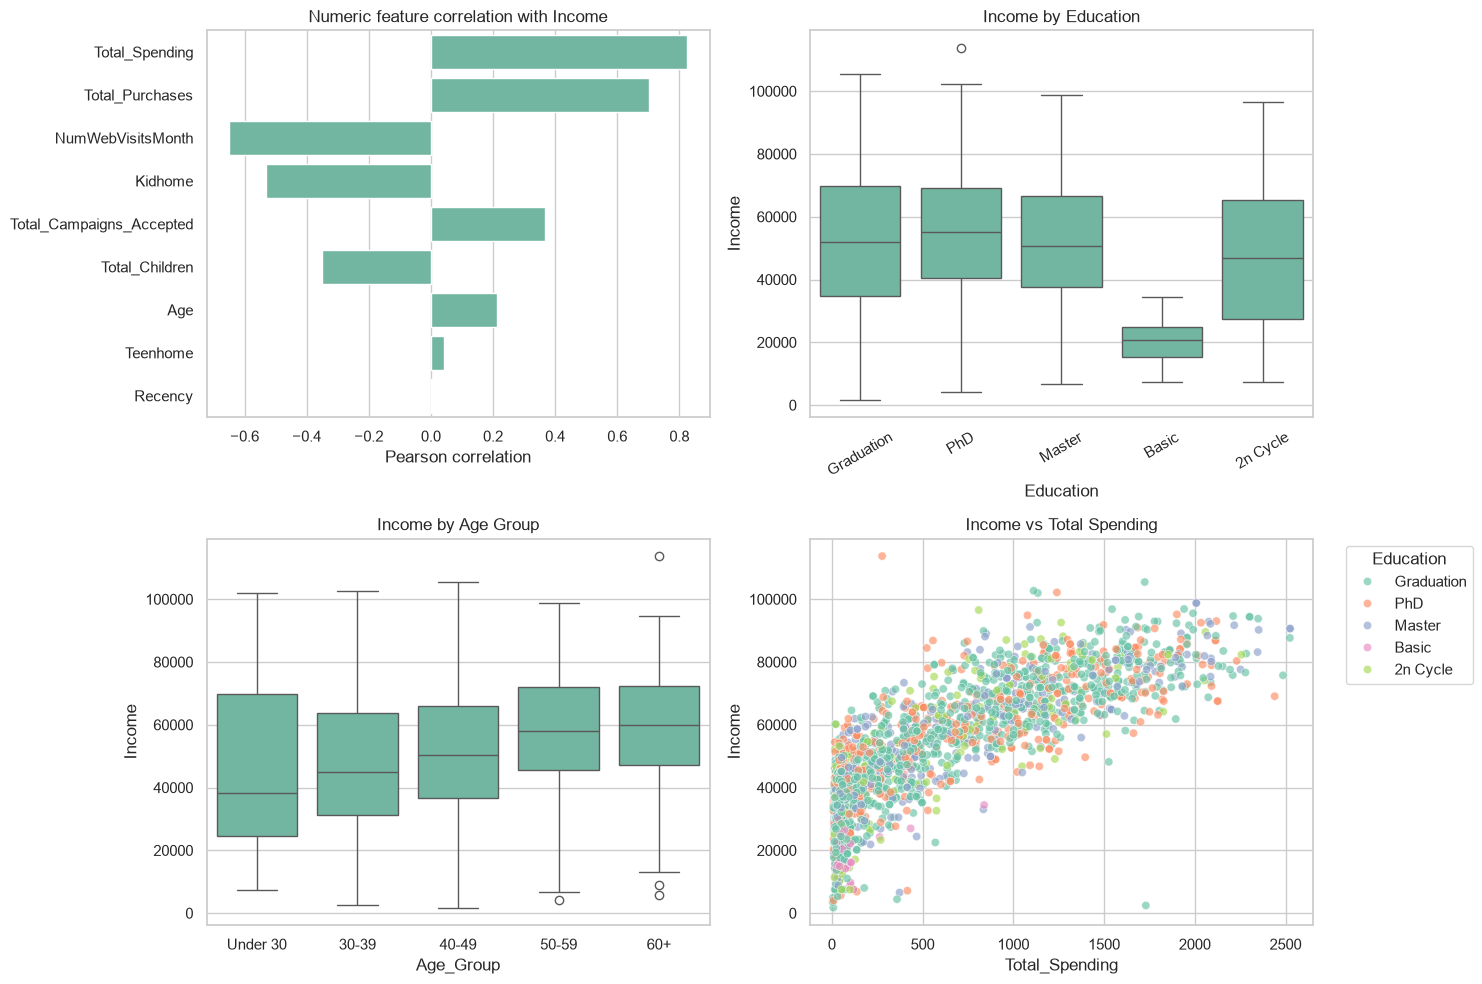

In [60]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(
    data=income_correlations.reset_index(),
    x="income_correlation",
    y="index",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Numeric feature correlation with Income")
axes[0, 0].set_xlabel("Pearson correlation")
axes[0, 0].set_ylabel("")

sns.boxplot(data=known_income, x="Education", y="Income", ax=axes[0, 1])
axes[0, 1].set_title("Income by Education")
axes[0, 1].tick_params(axis="x", rotation=30)

sns.boxplot(data=known_income, x="Age_Group", y="Income", ax=axes[1, 0])
axes[1, 0].set_title("Income by Age Group")

sns.scatterplot(
    data=known_income,
    x="Total_Spending",
    y="Income",
    hue="Education",
    alpha=0.65,
    ax=axes[1, 1],
)
axes[1, 1].set_title("Income vs Total Spending")
axes[1, 1].legend(title="Education", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

## Group Summary Tables

These tables compare income across education, age group, and number of children.

I looked at both mean and median, but median is better for filling income because income can be skewed by high values.


In [61]:
education_income_summary = known_income.groupby("Education")["Income"].agg(["count", "mean", "median"]).sort_values("median", ascending=False)
age_income_summary = known_income.groupby("Age_Group", observed=True)["Income"].agg(["count", "mean", "median"])
children_income_summary = known_income.groupby("Total_Children")["Income"].agg(["count", "mean", "median"])

display(education_income_summary)
display(age_income_summary)
display(children_income_summary)

,count,mean,median
Education,,,
PhD,474,55349.80,55185.00
Graduation,1111,51975.50,51948.00
Master,362,52570.02,50625.50
2n Cycle,200,47633.19,46805.00
Basic,54,20306.26,20744.00


,count,mean,median
Age_Group,,,
Under 30,293,46111.10,38197.00
30-39,599,47637.08,45057.00
40-49,620,51330.72,50442.00
50-59,463,57229.99,58113.00
60+,226,58700.94,59822.00


,count,mean,median
Total_Children,,,
0,627,65100.63,72099.00
1,1111,46969.43,47025.00
2,413,44307.83,44051.00
3,50,46677.00,44277.00


## Fill Missing Income Values

Missing income values are filled using grouped medians.

The notebook first tries specific groups like education, marital status, age group, and children. If that is too specific, it falls back to broader groups like education and age group, then education only, then the overall median.


In [62]:
income_by_full_profile = df.groupby(
    ["Education", "Marital_Status", "Age_Group", "Total_Children"], observed=True
)["Income"].transform("median")
income_by_education_age_children = df.groupby(
    ["Education", "Age_Group", "Total_Children"], observed=True
)["Income"].transform("median")
income_by_education_age = df.groupby(["Education", "Age_Group"], observed=True)["Income"].transform("median")
income_by_education = df.groupby("Education")["Income"].transform("median")
overall_income_median = df["Income"].median()

df["Income"] = (
    df["Income"]
    .fillna(income_by_full_profile)
    .fillna(income_by_education_age_children)
    .fillna(income_by_education_age)
    .fillna(income_by_education)
    .fillna(overall_income_median)
)

df.to_csv("cleaned_marketing_campaign.csv", index=False)

cleaning_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100).round(2),
    "unique_count": df.nunique(),
})

cleaning_summary

,dtype,missing_count,missing_percent,unique_count
ID,int64,0,0.00,2225
Year_Birth,int64,0,0.00,59
Education,str,0,0.00,5
Marital_Status,str,0,0.00,5
Income,float64,0,0.00,1977
Kidhome,int64,0,0.00,3
Teenhome,int64,0,0.00,3
Dt_Customer,datetime64[us],0,0.00,663
Recency,int64,0,0.00,100
MntWines,int64,0,0.00,775


## Final Cleaning Result

The cleaned dataset is saved as `cleaned_marketing_campaign.csv`.

This is the file used by the clustering notebooks.
